In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../data/raw/gaming_player_engagement.csv")
df.head()

,player_id,first_seen,last_seen,total_sessions,total_playtime_hours,avg_session_duration_minutes,total_revenue_usd,total_events,age,gender,location,game_genre,game_difficulty,play_time_hours_per_week,in_game_purchases,sessions_per_week,player_level,achievements_unlocked,engagement_level
0,P0000001,2024-07-21,2026-09-06,2023,3062.48,90.83,403.11,60838,31,Female,North America,Puzzle,Medium,25.74,75,17,89,73,High
1,P0000002,2026-02-21,2026-08-05,320,320.80,60.15,42.55,4833,19,Male,Asia,Action,Hard,14.04,14,14,62,19,Medium
2,P0000003,2025-04-13,2026-07-25,1029,1053.01,61.40,150.19,17562,35,Female,Europe,Puzzle,Hard,14.33,30,14,84,39,Medium
3,P0000004,2025-10-18,2026-09-10,302,308.24,61.24,39.71,7904,36,Male,Middle East,Puzzle,Hard,6.12,4,6,63,48,Low
4,P0000005,2025-06-18,2026-09-10,550,617.38,67.35,162.19,11632,13,Male,Oceania,RPG,Medium,11.22,17,10,73,65,Medium


In [4]:
df.shape


(10000, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   player_id                     10000 non-null  object 
 1   first_seen                    10000 non-null  object 
 2   last_seen                     10000 non-null  object 
 3   total_sessions                10000 non-null  int64  
 4   total_playtime_hours          10000 non-null  float64
 5   avg_session_duration_minutes  10000 non-null  float64
 6   total_revenue_usd             10000 non-null  float64
 7   total_events                  10000 non-null  int64  
 8   age                           10000 non-null  int64  
 9   gender                        10000 non-null  object 
 10  location                      10000 non-null  object 
 11  game_genre                    10000 non-null  object 
 12  game_difficulty               10000 non-null  object 
 13  pl

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.describe()


,total_sessions,total_playtime_hours,avg_session_duration_minutes,total_revenue_usd,total_events,age,play_time_hours_per_week,in_game_purchases,sessions_per_week,player_level,achievements_unlocked
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.0000,10000.000000
mean,858.150900,1125.937208,70.280925,194.679278,15470.060600,28.097800,14.483389,25.905000,11.03100,71.4461,39.555200
std,650.093322,1113.337360,27.278614,281.219692,14088.339396,8.662606,9.891188,25.753153,4.58139,15.5128,15.917842
min,1.000000,0.080000,5.000000,0.000000,15.000000,13.000000,0.080000,0.000000,1.00000,6.0000,0.000000
25%,330.000000,293.920000,50.765000,33.690000,4975.500000,22.000000,6.437500,7.000000,8.00000,63.0000,27.000000
50%,724.000000,773.855000,70.410000,99.535000,11342.000000,28.000000,12.710000,18.000000,11.00000,74.0000,38.000000
75%,1251.000000,1606.035000,89.962500,246.427500,21936.000000,34.000000,20.952500,37.000000,14.00000,82.0000,51.000000
max,3550.000000,7511.950000,168.670000,5669.800000,98294.000000,64.000000,58.340000,162.000000,24.00000,100.0000,94.000000


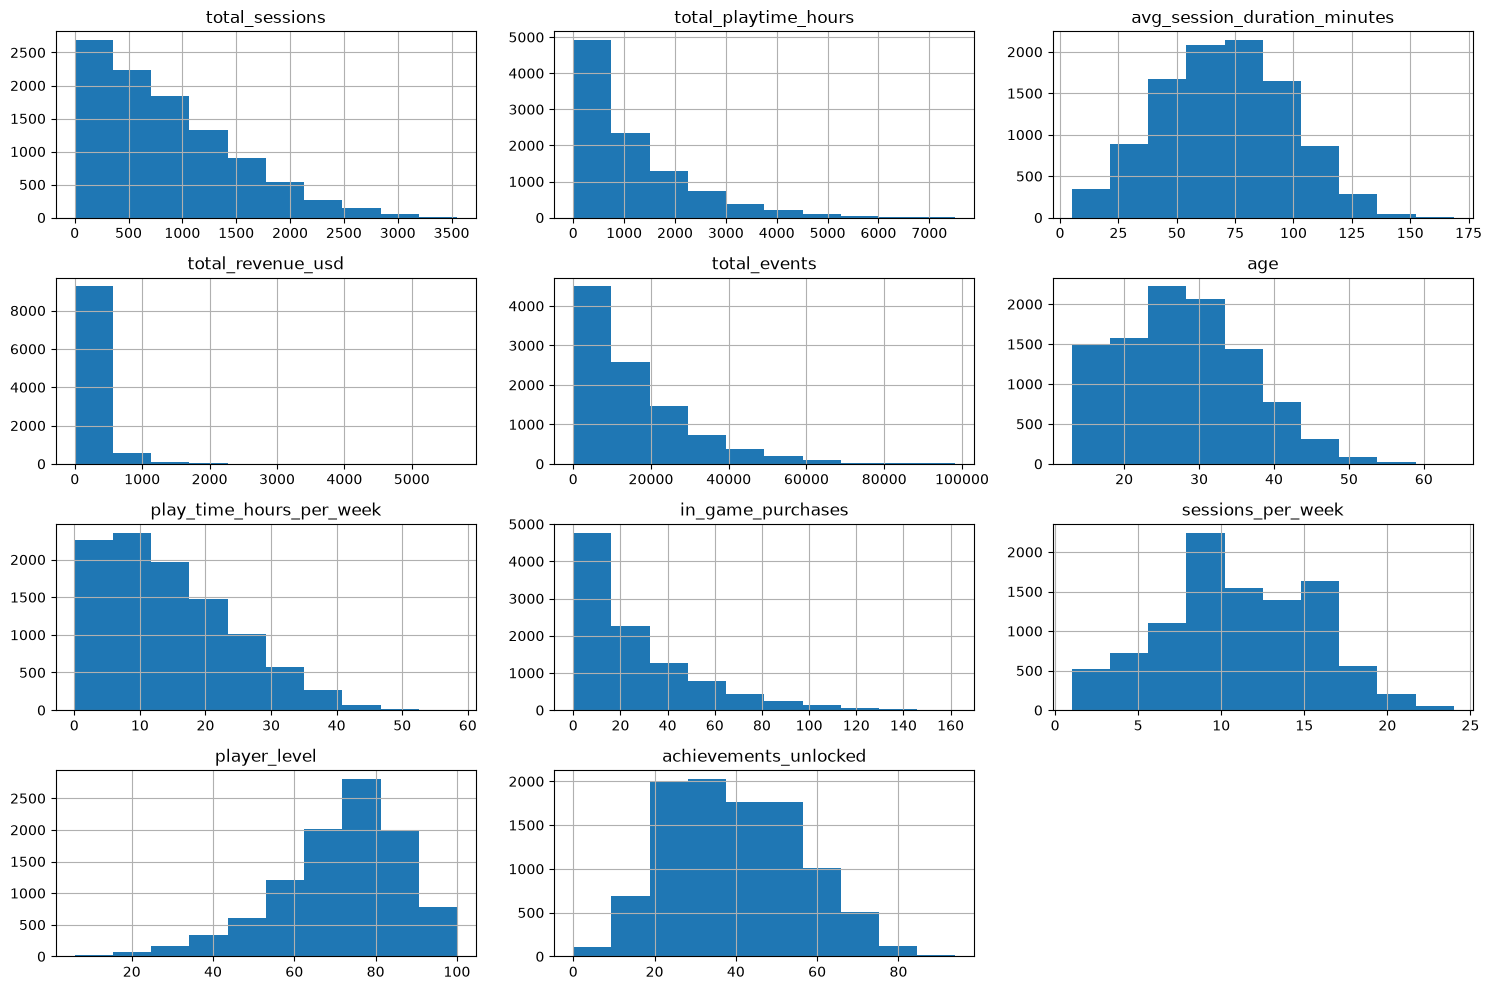

In [8]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

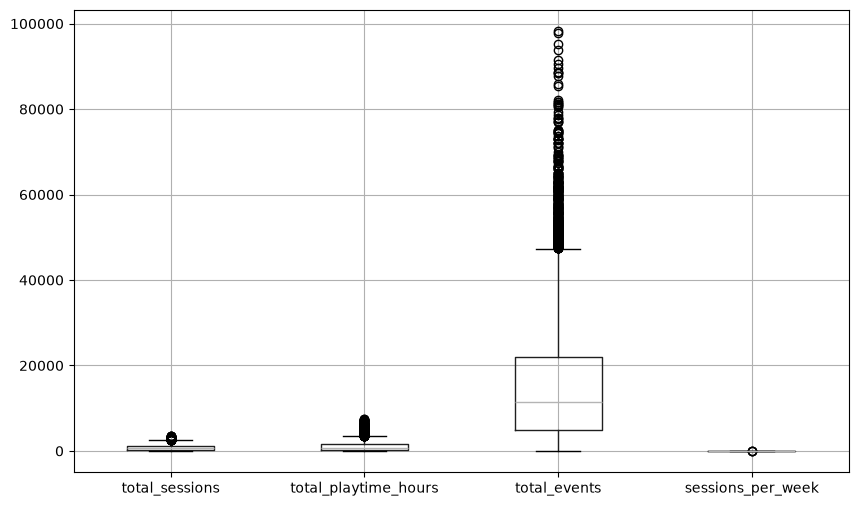

In [9]:
df[["total_sessions", "total_playtime_hours", "total_events", "sessions_per_week"]].boxplot(figsize=(10, 6))
plt.show()

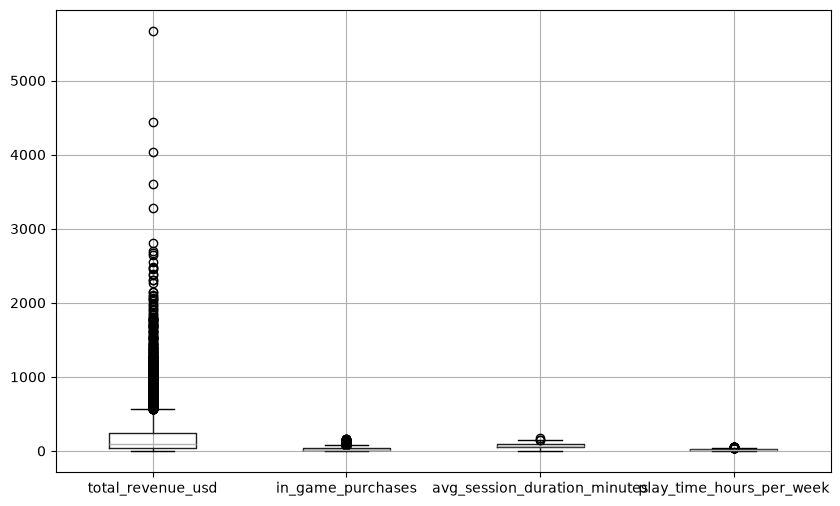

In [10]:
df[["total_revenue_usd", "in_game_purchases", "avg_session_duration_minutes", "play_time_hours_per_week"]].boxplot(figsize=(10, 6))
plt.show()

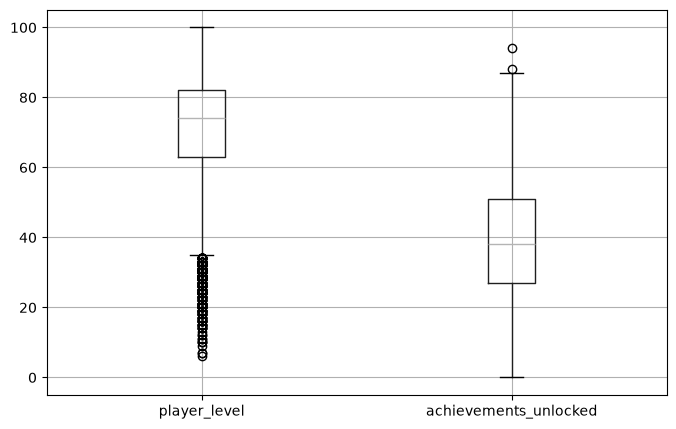

In [11]:
df[["player_level", "achievements_unlocked"]].boxplot(figsize=(8, 5))
plt.show()

In [12]:
df.select_dtypes(include="object").nunique()

player_id           10000
first_seen           1082
last_seen              74
gender                  4
location                7
game_genre              7
game_difficulty         3
engagement_level        3
dtype: int64

In [13]:
df["gender"].value_counts()

gender
Male                 4717
Female               4581
Non-binary            410
Prefer not to say     292
Name: count, dtype: int64

In [14]:
df["location"].value_counts()

location
Asia             3009
North America    2471
Europe           2283
South America     863
Oceania           495
Africa            475
Middle East       404
Name: count, dtype: int64

In [15]:
df["game_genre"].value_counts()

game_genre
Action        2332
RPG           2019
Adventure     1389
Strategy      1330
Sports        1190
Simulation     932
Puzzle         808
Name: count, dtype: int64

In [16]:
df["game_difficulty"].value_counts()

game_difficulty
Medium    5042
Hard      2486
Easy      2472
Name: count, dtype: int64

In [17]:
df["engagement_level"].value_counts()

engagement_level
Medium    4000
Low       3500
High      2500
Name: count, dtype: int64

In [18]:
df.groupby("engagement_level")["total_revenue_usd"].mean()

engagement_level
High      389.699912
Low        62.953257
Medium    188.051650
Name: total_revenue_usd, dtype: float64

In [19]:
df.groupby("engagement_level")["sessions_per_week"].mean()

engagement_level
High      16.508000
Low        6.278286
Medium    11.766500
Name: sessions_per_week, dtype: float64

In [20]:
df.groupby("engagement_level")["play_time_hours_per_week"].mean()

engagement_level
High      27.579212
Low        4.887880
Medium    14.694570
Name: play_time_hours_per_week, dtype: float64

<Axes: xlabel='engagement_level', ylabel='total_revenue_usd'>

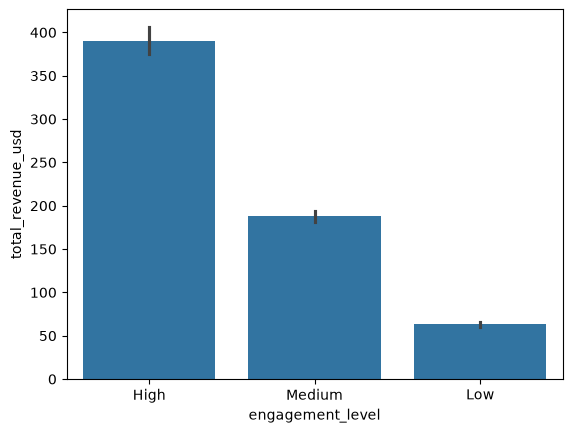

In [21]:
import seaborn as sns
sns.barplot(data=df, x="engagement_level", y="total_revenue_usd")

<Axes: xlabel='engagement_level', ylabel='count'>

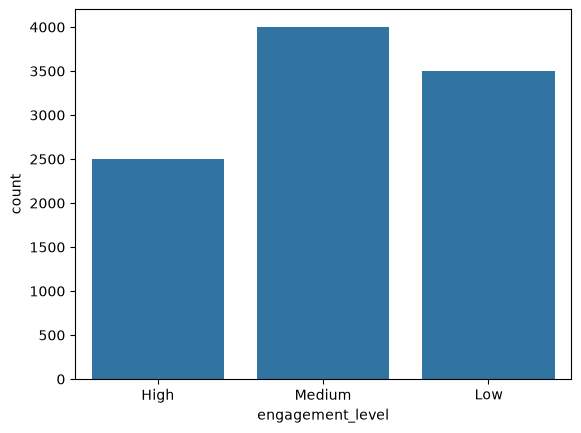

In [22]:
sns.countplot(data=df, x="engagement_level")

<Axes: xlabel='engagement_level', ylabel='sessions_per_week'>

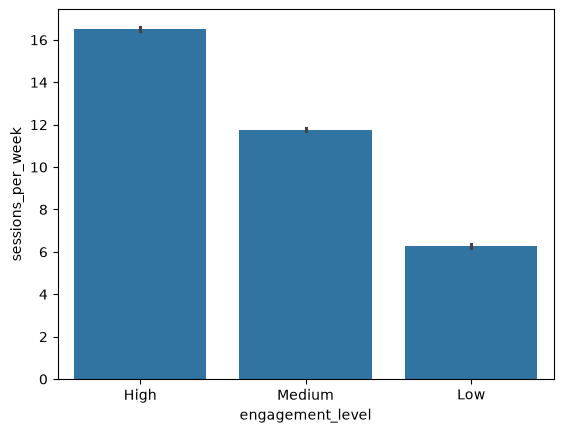

In [23]:
sns.barplot(data=df, x="engagement_level", y="sessions_per_week")

<Axes: xlabel='engagement_level', ylabel='play_time_hours_per_week'>

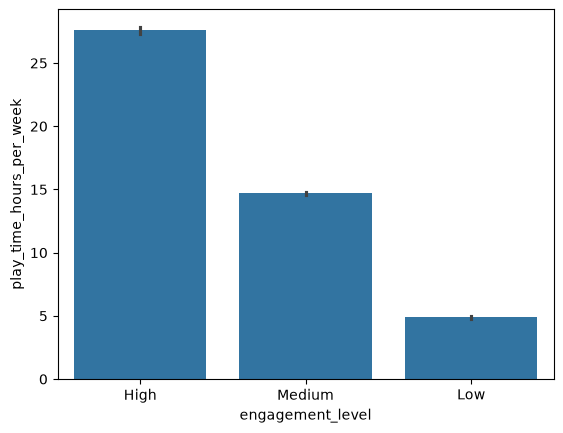

In [24]:
sns.barplot(data=df, x="engagement_level", y="play_time_hours_per_week")

In [25]:
pd.crosstab(df["game_genre"], df["game_difficulty"])

game_difficulty,Easy,Hard,Medium
game_genre,,,
Action,551,584,1197
Adventure,354,353,682
Puzzle,193,190,425
RPG,514,499,1006
Simulation,249,217,466
Sports,282,294,614
Strategy,329,349,652


In [26]:
pd.crosstab(df["game_genre"], df["in_game_purchases"]>0)

in_game_purchases,False,True
game_genre,,
Action,109,2223
Adventure,66,1323
Puzzle,30,778
RPG,77,1942
Simulation,48,884
Sports,56,1134
Strategy,59,1271


In [27]:
pd.crosstab(df["game_genre"],df["in_game_purchases"]>0,normalize="index")

in_game_purchases,False,True
game_genre,,
Action,0.046741,0.953259
Adventure,0.047516,0.952484
Puzzle,0.037129,0.962871
RPG,0.038138,0.961862
Simulation,0.051502,0.948498
Sports,0.047059,0.952941
Strategy,0.044361,0.955639


<Axes: xlabel='game_genre', ylabel='in_game_purchases'>

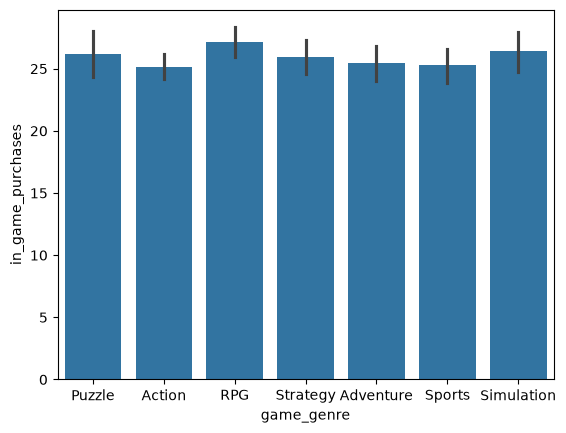

In [28]:
sns.barplot(x= "game_genre",y = "in_game_purchases",data = df)

<Axes: xlabel='game_genre', ylabel='True'>

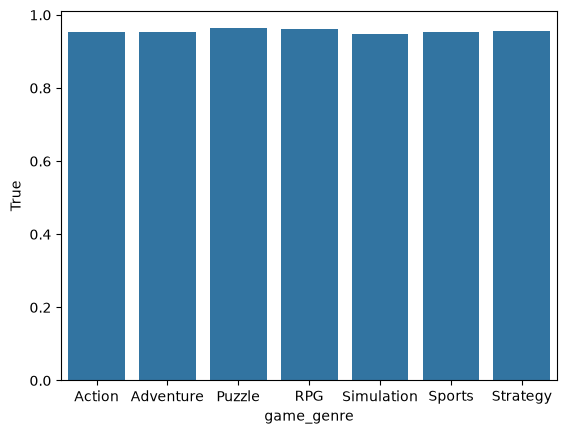

In [29]:
purchase_rate = pd.crosstab(
    df["game_genre"],
    df["in_game_purchases"] > 0,
    normalize="index"
)

sns.barplot(
    x=purchase_rate.index,
    y=purchase_rate[True]
)


In [30]:
corr = df.select_dtypes(include=np.number).corr()

corr

,total_sessions,total_playtime_hours,avg_session_duration_minutes,total_revenue_usd,total_events,age,play_time_hours_per_week,in_game_purchases,sessions_per_week,player_level,achievements_unlocked
total_sessions,1.000000,0.926734,0.408563,0.654114,0.831538,0.000607,0.498431,0.935004,0.540333,0.781937,0.436624
total_playtime_hours,0.926734,1.000000,0.628260,0.668974,0.776106,-0.004952,0.691145,0.955098,0.630060,0.754679,0.423373
avg_session_duration_minutes,0.408563,0.628260,1.000000,0.373851,0.347040,-0.014124,0.908744,0.536222,0.750104,0.601664,0.332367
total_revenue_usd,0.654114,0.668974,0.373851,1.000000,0.551674,-0.001653,0.455743,0.702492,0.456873,0.508316,0.283119
total_events,0.831538,0.776106,0.347040,0.551674,1.000000,0.005832,0.418393,0.782129,0.447284,0.653820,0.367912
age,0.000607,-0.004952,-0.014124,-0.001653,0.005832,1.000000,-0.018395,-0.004104,-0.016396,0.004261,0.006705
play_time_hours_per_week,0.498431,0.691145,0.908744,0.455743,0.418393,-0.018395,1.000000,0.644860,0.916743,0.590628,0.326483
in_game_purchases,0.935004,0.955098,0.536222,0.702492,0.782129,-0.004104,0.644860,1.000000,0.645671,0.731438,0.405945
sessions_per_week,0.540333,0.630060,0.750104,0.456873,0.447284,-0.016396,0.916743,0.645671,1.000000,0.605404,0.330610
player_level,0.781937,0.754679,0.601664,0.508316,0.653820,0.004261,0.590628,0.731438,0.605404,1.000000,0.554738


<Axes: >

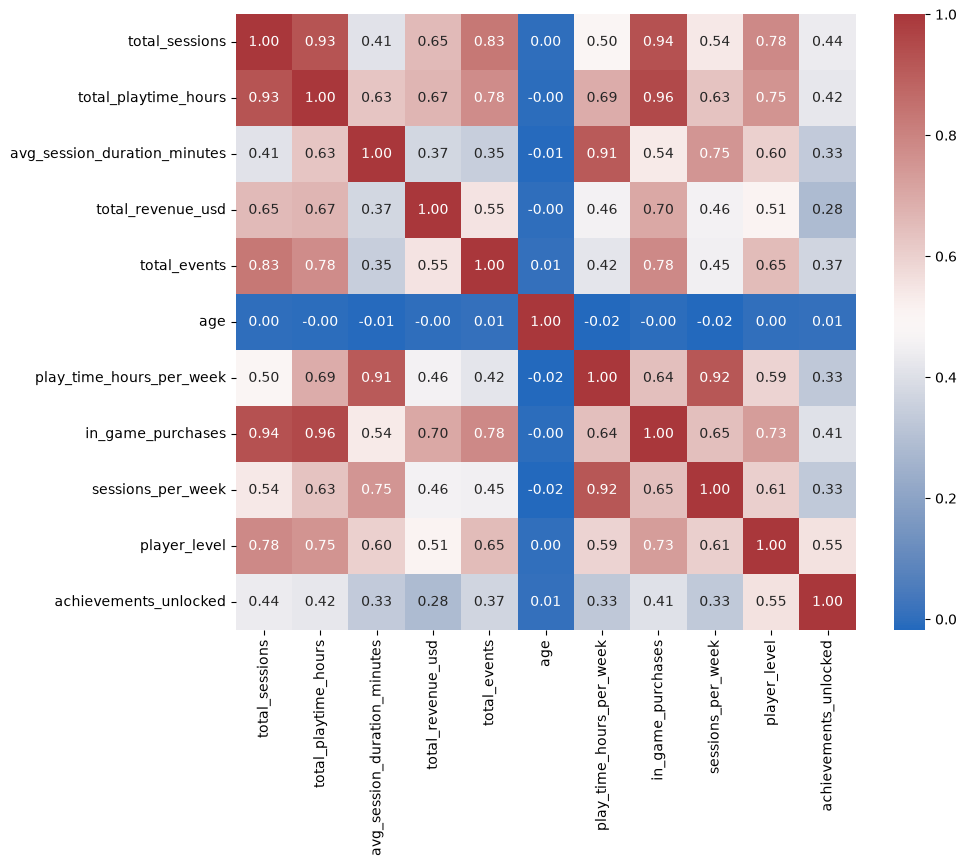

In [31]:
plt.figure(figsize = (10,8))
sns.heatmap(corr,annot=True,cmap="vlag",fmt = ".2f")

<Axes: xlabel='play_time_hours_per_week', ylabel='total_revenue_usd'>

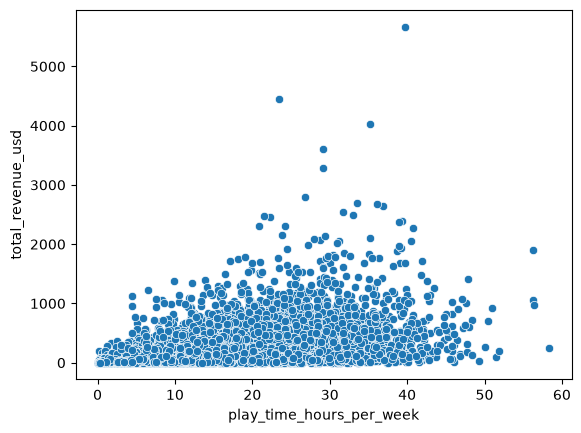

In [32]:
sns.scatterplot(
    data=df,
    x="play_time_hours_per_week",
    y="total_revenue_usd"
)

In [33]:
corr["total_revenue_usd"].sort_values(ascending=False)

total_revenue_usd               1.000000
in_game_purchases               0.702492
total_playtime_hours            0.668974
total_sessions                  0.654114
total_events                    0.551674
player_level                    0.508316
sessions_per_week               0.456873
play_time_hours_per_week        0.455743
avg_session_duration_minutes    0.373851
achievements_unlocked           0.283119
age                            -0.001653
Name: total_revenue_usd, dtype: float64

In [35]:
from scipy.stats import ttest_ind

high = df[df["engagement_level"] == "High"]["total_revenue_usd"]
low = df[df["engagement_level"] == "Low"]["total_revenue_usd"]

t_stat, p_value = ttest_ind(high, low,equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 38.43658036145729
p-value: 1.8399581452803007e-257


In [37]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df["game_genre"],df["in_game_purchases"]>0)
chi2,p_value,dof,expected = chi2_contingency(table)
print("chisq value : " ,chi2)
print("p val : ",p_value)


chisq value :  4.78581301853258
p val :  0.571563137258329


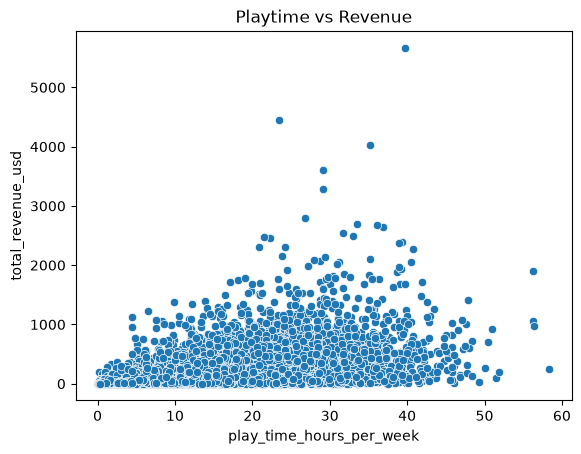

In [39]:
sns.scatterplot(
    data=df,
    x="play_time_hours_per_week",
    y="total_revenue_usd"
)

plt.title("Playtime vs Revenue")
plt.show()

In [44]:
df["first_seen"] = pd.to_datetime(df["first_seen"])
df["last_seen"] = pd.to_datetime(df["last_seen"])

snapshot = df["last_seen"].max()

df["days_since_last_seen"] = (
    snapshot - df["last_seen"]
).dt.days

df["account_age_days"] = (
    df["last_seen"] - df["first_seen"]
).dt.days.clip(lower=1)

In [45]:
target = df["purchase_flag"] = (
    df["in_game_purchases"] > 0
).astype(int)

In [46]:
features = [
    "age",
    "gender",
    "location",
    "game_genre",
    "game_difficulty",
    "sessions_per_week",
    "avg_session_duration_minutes",
    "player_level",
    "achievements_unlocked",
    "total_events",
    "days_since_last_seen",
    "account_age_days"
]

X = df[features]
y = df["purchase_flag"]

In [47]:
print(X.shape)
print(X.columns)
print(y.value_counts())

(10000, 12)
Index(['age', 'gender', 'location', 'game_genre', 'game_difficulty',
       'sessions_per_week', 'avg_session_duration_minutes', 'player_level',
       'achievements_unlocked', 'total_events', 'days_since_last_seen',
       'account_age_days'],
      dtype='object')
purchase_flag
1    9555
0     445
Name: count, dtype: int64


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer


In [50]:
numeric_features = [
    "age",
    "sessions_per_week",
    "avg_session_duration_minutes",
    "player_level",
    "achievements_unlocked",
    "total_events",
    "days_since_last_seen",
    "account_age_days"
]

categorical_features = [
    "gender",
    "location",
    "game_genre",
    "game_difficulty"
]

In [51]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [52]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [53]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [54]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'sessions_per_week',
                                  'avg_session_duration_minutes',
                                  'player_level', 'achievements_unlocked',
                                  'total_events', 'days_since_last_seen',
                                  'account_age_days']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'location', 'game_genre',
                                  'game_difficulty'])])

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [85]:
models = {
    "Logistic Regression": LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

In [90]:
def evaluate_models(models, preprocessor, X_train, X_test, y_train, y_test):
    results = {}

    for name, model in models.items():

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        results[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        }

    return results


In [91]:
results = evaluate_models(
    models,
    preprocessor,
    X_train,
    X_test,
    y_train,
    y_test
)

results_df = pd.DataFrame(results).T
results_df

c:\Users\KARTIK SRIBVASTAVA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9675,0.975773,0.990581,0.983121,0.972889
Random Forest,0.9655,0.970378,0.994244,0.982166,0.968729


In [93]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ))
])

best_model.fit(X_train, y_train)

c:\Users\KARTIK SRIBVASTAVA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sessions_per_week',
                                                   'avg_session_duration_minutes',
                                                   'player_level',
                                                   'achievements_unlocked',
                                                   'total_events',
                                                   'days_since_last_seen',
                                                   'account_age_days']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'location',
                                                   'game_genre',
                                                   'game_difficulty'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [97]:
import joblib

joblib.dump(best_model, "purchase_model.pkl")

['purchase_model.pkl']